In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
bechdel_scores = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/bechdel_scores.csv')
bechdel_scores['title'] = bechdel_scores['title'].str.lower()

In [3]:
bechdel_scores

,year,id,imdbid,title,rating
0,1874,9602,3155794.0,passage de venus,0
1,1877,9804,14495706.0,la rosace magique,0
2,1878,9603,2221420.0,sallie gardner at a gallop,0
3,1878,9806,12592084.0,le singe musicien,0
4,1881,9816,7816420.0,athlete swinging a pick,0
...,...,...,...,...,...
10557,2025,11779,29603959.0,novocaine,1
10558,2025,11785,30840798.0,"phoenician scheme, the",3
10559,2025,11786,32550101.0,straw,3
10560,2025,11787,30253473.0,materialists,3


In [3]:
title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.basics.tsv', sep='\t')
title_ratings=pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.ratings.tsv', sep='\t')
title_all = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.akas.tsv', sep='\t')
title_ratings  = title_ratings.rename(columns={'tconst': 'titleId'})
title_basics  = title_basics.rename(columns={'tconst': 'titleId'})
title_all=title_all.drop(['region', 'types', 'attributes'], axis =1)
title_all = title_all[title_all['isOriginalTitle'] == 1]
title_all=title_all.merge(title_ratings, on='titleId').merge(title_basics, on='titleId')
oscar_winning = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/oscars_df.csv')
oscar_winning
oscar_winning=oscar_winning.drop(['Unnamed: 0', 'Oscar Year'], axis=1)
oscar_winning=oscar_winning.rename(columns={'Film' : 'title'})
oscar_winning = set(oscar_winning['title'].str.lower())
title_all['oscar'] = title_all['title'].str.lower().apply(lambda x: 1 if x in oscar_winning else 0)
title_all=title_all.drop(['isOriginalTitle', 'language', 'ordering'], axis=1)
def remove_leading_zeros(s):
    return s.lstrip('0') or '0'

title_all['titleId']=title_all['titleId'].str.replace('t', '')
title_all['titleId']= [remove_leading_zeros(num) for num in title_all['titleId']]
title_all['titleId']= title_all['titleId'].astype(int)
title_all=title_all.rename(columns={'titleId' : 'imdbid'})

/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_62632/1876048893.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  title_basics = pd.read_csv('/Users/brookeye/RISE/Bechdel_Final/Data/1. InputData/title.basics.tsv', sep='\t')


In [16]:
df = bechdel_scores.merge(title_all, on='imdbid')

In [17]:
df=df[df['titleType']=='movie']
df=df[df['numVotes']>=1000]
df=df.drop(['title_y', 'startYear', 'endYear', 'isAdult', 'primaryTitle', 'titleType', 'originalTitle', 'id'], axis=1)

df=df.rename(columns={'movie_idx' : 'movie_id', 'title_x': 'title', 'rating': 'bechdel_score', 'averageRating': 'imdb_score'})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8980 entries, 114 to 10512
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            8980 non-null   int64  
 1   imdbid          8980 non-null   float64
 2   title           8980 non-null   object 
 3   bechdel_score   8980 non-null   int64  
 4   imdb_score      8980 non-null   float64
 5   numVotes        8980 non-null   int64  
 6   runtimeMinutes  8980 non-null   object 
 7   genres          8980 non-null   object 
 8   oscar           8980 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 701.6+ KB


In [18]:
# Assuming your DataFrame is called df and has a 'genre' column
# First get all unique genres by splitting and exploding
all_genres = df['genres'].str.split(',').explode().unique()

# Create a new DataFrame with binary columns for each genre
for genre in all_genres:
    df[f'genre_{genre}'] = df['genres'].str.contains(genre, regex=False).astype(int)

df = df.drop('genres', axis=1)

In [19]:
mask = (
    (df.get('genre_Adult', 0) != 1) & 
    (df.get('genre_News', 0) != 1) & 
    (df.get('genre_\\N', 0) != 1)
)

# Apply the filter
df = df[mask].copy()

df = df.drop(columns=['genre_Adult', 'genre_News', 'genre_\\N'], errors='ignore')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8977 entries, 114 to 10512
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               8977 non-null   int64  
 1   imdbid             8977 non-null   float64
 2   title              8977 non-null   object 
 3   bechdel_score      8977 non-null   int64  
 4   imdb_score         8977 non-null   float64
 5   numVotes           8977 non-null   int64  
 6   runtimeMinutes     8977 non-null   object 
 7   oscar              8977 non-null   int64  
 8   genre_Action       8977 non-null   int64  
 9   genre_Adventure    8977 non-null   int64  
 10  genre_Biography    8977 non-null   int64  
 11  genre_Drama        8977 non-null   int64  
 12  genre_War          8977 non-null   int64  
 13  genre_History      8977 non-null   int64  
 14  genre_Comedy       8977 non-null   int64  
 15  genre_Family       8977 non-null   int64  
 16  genre_Romance      8977 no

<Figure size 1200x600 with 0 Axes>

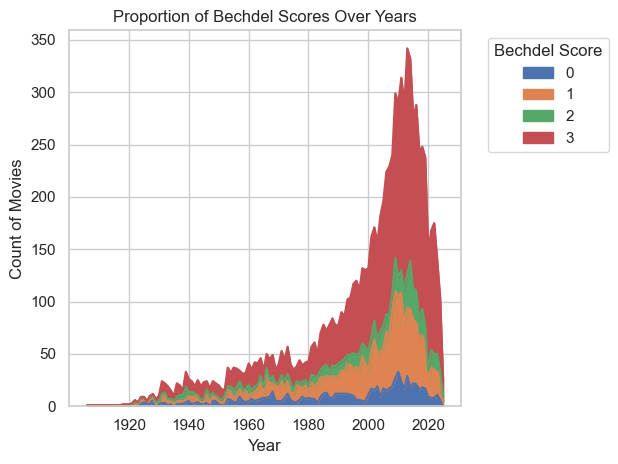

In [21]:
plt.figure(figsize=(12, 6))
df.groupby(['year', 'bechdel_score']).size().unstack().plot(kind='area', stacked=True)
plt.title('Proportion of Bechdel Scores Over Years')
plt.xlabel('Year')
plt.ylabel('Count of Movies')
plt.legend(title='Bechdel Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/mm/8lwyn74n6wj3qytmg8w_39bm0000gn/T/ipykernel_62632/387851798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bechdel_score', y='imdb_score', palette='coolwarm')


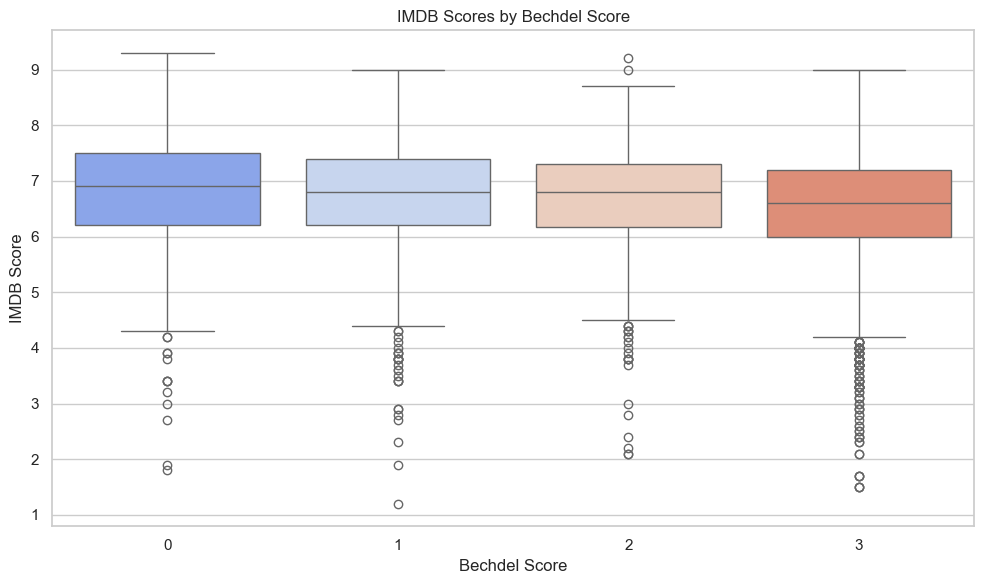

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bechdel_score', y='imdb_score', palette='coolwarm')
plt.title('IMDB Scores by Bechdel Score')
plt.xlabel('Bechdel Score')
plt.ylabel('IMDB Score')
plt.tight_layout()
plt.show()

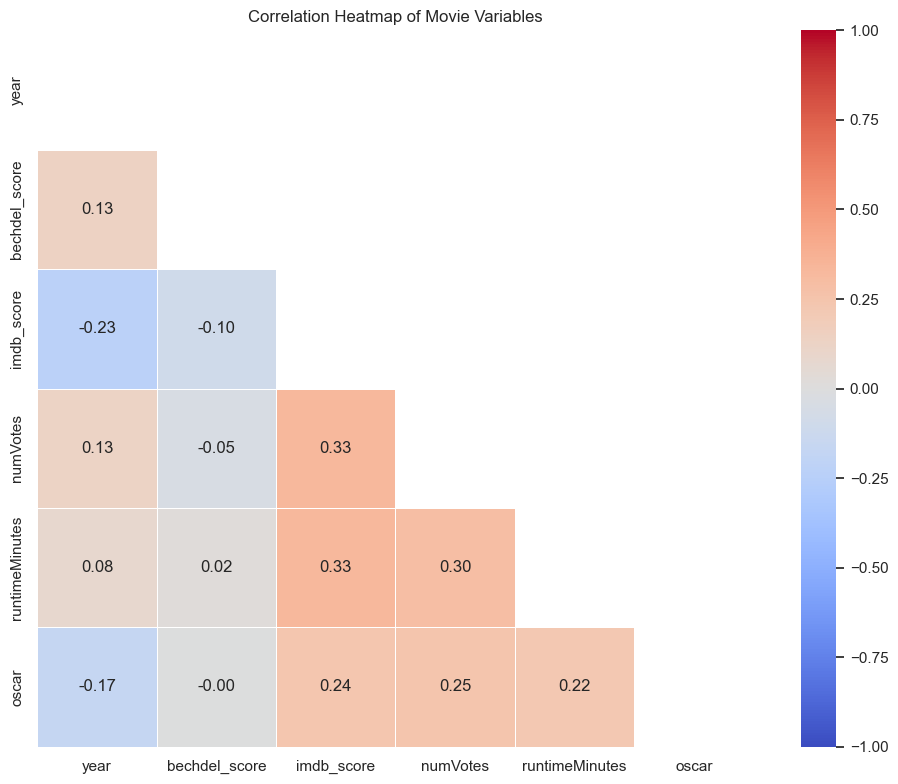

In [25]:
heatmap_df = df.copy()

# Convert 'runtimeMinutes' to numeric (handling any potential non-numeric values)
heatmap_df['runtimeMinutes'] = pd.to_numeric(heatmap_df['runtimeMinutes'], errors='coerce')

# For categorical variables, we could create dummy variables if needed
# But for simplicity, we'll just include numerical columns for this heatmap
numerical_cols = ['year', 'bechdel_score', 'imdb_score', 'numVotes', 'runtimeMinutes', 'oscar']
heatmap_df = heatmap_df[numerical_cols]

# 2. Calculate correlation matrix
corr = heatmap_df.corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mask upper triangle for cleaner look

sns.heatmap(corr, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=.5)

plt.title('Correlation Heatmap of Movie Variables')
plt.grid(False)
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

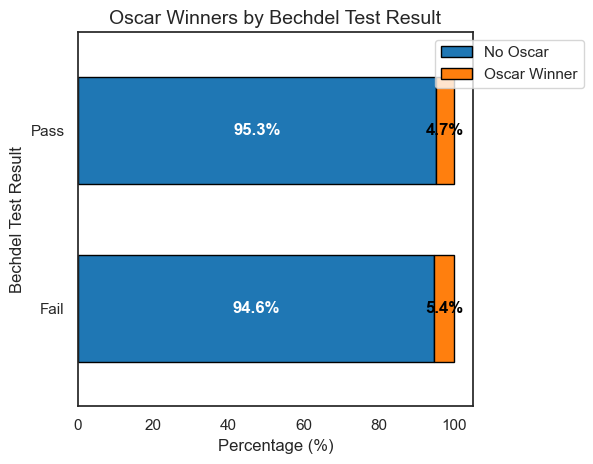

In [29]:
# Create a new DataFrame for analysis (preserves original 'df')
bechdel_oscar = pd.DataFrame({
    'bechdel_pass': df['bechdel_score'].apply(lambda x: 'Pass' if x == 3 else 'Fail'),
    'oscar': df['oscar'].map({0: 'No Oscar', 1: 'Oscar Winner'})  # Optional: Rename for clarity
})
# Compute percentages (normalized by Bechdel Pass/Fail)
cross_tab = pd.crosstab(
    index=bechdel_oscar['bechdel_pass'],
    columns=bechdel_oscar['oscar'],
    normalize='index'  # Row-wise percentages
) * 100

plt.figure(figsize=(8, 4))
ax = cross_tab.plot(
    kind='barh',
    stacked=True,
    color=['#1f77b4', '#ff7f0e'],  # Blue (No Oscar), Orange (Oscar)
    width=0.6,
    edgecolor='black'
)

# Customize the plot
plt.title('Oscar Winners by Bechdel Test Result', fontsize=14)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Bechdel Test Result', fontsize=12)
plt.legend(bbox_to_anchor=(1.3, 1), loc='upper right')  # Move legend outside
plt.grid(False)

# Add percentage labels
for i, (no_oscar, oscar) in enumerate(zip(cross_tab['No Oscar'], cross_tab['Oscar Winner'])):
    ax.text(no_oscar / 2, i, f'{no_oscar:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(no_oscar + oscar / 2, i, f'{oscar:.1f}%', ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

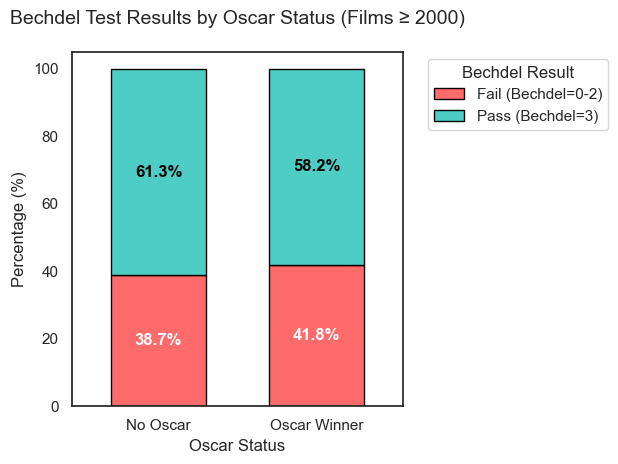

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter films (2000+), add Bechdel Pass/Fail (no original DF modification)
recent_films = df[df['year'] >= 2000].copy()
recent_films['bechdel_pass'] = recent_films['bechdel_score'].apply(
    lambda x: 'Pass (Bechdel=3)' if x == 3 else 'Fail (Bechdel=0-2)'
)

# 2. Compute percentages (stacked)
cross_tab = pd.crosstab(
    index=recent_films['oscar'].map({0: 'No Oscar', 1: 'Oscar Winner'}),
    columns=recent_films['bechdel_pass'],
    normalize='index'  # Row-wise percentages
) * 100

# 3. Plot stacked bars
plt.figure(figsize=(8, 5))
ax = cross_tab.plot(
    kind='bar',
    stacked=True,
    color=['#ff6b6b', '#4ecdc4'],  # Red (Fail), Teal (Pass)
    edgecolor='black',
    width=0.6
)

# 4. Customize plot
plt.title('Bechdel Test Results by Oscar Status (Films ≥ 2000)', fontsize=14, pad=20)
plt.xlabel('Oscar Status', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(False)

# 5. Add percentage labels
for i, (fail_pct, pass_pct) in enumerate(zip(cross_tab['Fail (Bechdel=0-2)'], cross_tab['Pass (Bechdel=3)'])):
    # Label for Fail (bottom segment)
    ax.text(i, fail_pct / 2, f'{fail_pct:.1f}%', 
            ha='center', va='center', color='white', fontweight='bold')
    # Label for Pass (top segment)
    ax.text(i, fail_pct + pass_pct / 2, f'{pass_pct:.1f}%', 
            ha='center', va='center', color='black', fontweight='bold')

plt.legend(title='Bechdel Result', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()